# CV-IPCW-L1MLE Survival APIs Demo

This notebook demonstrates two separate survival estimators built from the post-IPCW L1 path:

1. `CV-IPCW-L1MLE` (no undersmoothing, factor 1.0)
2. `Plug-in undersmoothed CV-IPCW-L1MLE` (score-solving factor selection)

It also shows how to run them with and without conservative adjustment in Stage 1 and inspect EIF/threshold score-solving diagnostics.

In [1]:
from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from haldensity.censoring.right.comparison import (
    evaluate_density_on_grid,
    evaluate_survival_on_grid,
    fit_right_censored_cv_ipcw_l1mle_plugin,
    fit_right_censored_cv_ipcw_l1mle_undersmoothed_plugin,
    simulate_beta_uniform_right_censored,
)

plt.style.use("seaborn-v0_8-whitegrid")

/Users/houyilong/GitHub/HALDensity/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
SEED = 17
TARGETING_POINTS = np.round(np.linspace(0.1, 0.9, 9), 2)

COMMON_KWARGS = {
    "cv_folds": 3,
    "n_trials": 10,
    "random_state": SEED,
    "n_grid_points": 150,
    "stage1_param_overrides": {
        "basis_order": [0, 1],
        "norm_constraint": {"low": 3.0, "high": 30.0, "log": True},
    },
    "norm_constraint_factors": [1.0, 1.1, 1.2, 1.4, 1.6],
    "l1_kwargs": {
        "n_grid_points": 150,
        "learning_rate": 0.1,
        "n_iterations": 300,
        "ll_change_tol": 1e-4,
        "history_every": 100,
    },
}

sim = simulate_beta_uniform_right_censored(n=260, seed=SEED)
data = sim["observed_data"]
truth = sim["truth"]

print("n:", len(data))
print("event rate:", float(data["Delta"].mean()))
print("targeting points:", TARGETING_POINTS.tolist())

n: 260
event rate: 0.5230769230769231
targeting points: [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]


## Run APIs Without Conservative Adjustment

This run keeps Stage 1 CV-IPCW selection at the plain argmax of CV IPCW log-likelihood.

In [3]:
plugin_no_cons = fit_right_censored_cv_ipcw_l1mle_plugin(
    data,
    targeting_points=TARGETING_POINTS,
    truth=truth,
    stage1_tuner_kwargs={
        "silent": True,
        "use_conservative_adjustment": False,
    },
    **COMMON_KWARGS,
)

undersmoothed_no_cons = fit_right_censored_cv_ipcw_l1mle_undersmoothed_plugin(
    data,
    targeting_points=TARGETING_POINTS,
    truth=truth,
    stage1_tuner_kwargs={
        "silent": True,
        "use_conservative_adjustment": False,
    },
    **COMMON_KWARGS,
)

plugin_no_cons["no_undersmoothing_summary"].head()

,t0,psi_init,estimated_density,truth_survival,abs_error_plugin,sq_error_plugin,truth_density,density_abs_error,density_sq_error,norm_factor,norm_constraint
0,0.1,0.954830,0.586266,0.972839,0.018009,0.000324,0.567583,0.018683,3.490480e-04,1.0,13.597366
1,0.2,0.876809,1.012609,0.888675,0.011866,0.000141,1.092790,0.080181,6.428979e-03,1.0,13.597366
2,0.3,0.747346,1.454765,0.759777,0.012431,0.000155,1.454984,0.000219,4.793390e-08,1.0,13.597366
3,0.4,0.598130,1.530174,0.603920,0.005790,0.000034,1.630664,0.100490,1.009826e-02,1.0,13.597366
4,0.5,0.444318,1.463243,0.439826,0.004492,0.000020,1.621380,0.158136,2.500712e-02,1.0,13.597366


## Run APIs With Conservative Adjustment (5% * SD)

This run enables Stage 1 conservative selection using the legacy `5% * SD` threshold rule (`legacy_percent_sd` + `conservative_k_percent=0.05`).

In [4]:
plugin_cons = fit_right_censored_cv_ipcw_l1mle_plugin(
    data,
    targeting_points=TARGETING_POINTS,
    truth=truth,
    stage1_tuner_kwargs={
        "silent": True,
        "use_conservative_adjustment": True,
        "conservative_selection_rule": "legacy_percent_sd",
        "conservative_k_percent": 0.05,
    },
    **COMMON_KWARGS,
)

undersmoothed_cons = fit_right_censored_cv_ipcw_l1mle_undersmoothed_plugin(
    data,
    targeting_points=TARGETING_POINTS,
    truth=truth,
    stage1_tuner_kwargs={
        "silent": True,
        "use_conservative_adjustment": True,
        "conservative_selection_rule": "legacy_percent_sd",
        "conservative_k_percent": 0.05,
    },
    **COMMON_KWARGS,
)

plugin_cons["no_undersmoothing_summary"].head()

,t0,psi_init,estimated_density,truth_survival,abs_error_plugin,sq_error_plugin,truth_density,density_abs_error,density_sq_error,norm_factor,norm_constraint
0,0.1,0.933773,0.739963,0.972839,0.039067,0.001526,0.567583,0.172380,0.029715,1.0,6.725448
1,0.2,0.850736,0.927778,0.888675,0.037939,0.001439,1.092790,0.165011,0.027229,1.0,6.725448
2,0.3,0.746624,1.163264,0.759777,0.013154,0.000173,1.454984,0.291720,0.085101,1.0,6.725448
3,0.4,0.616086,1.458520,0.603920,0.012166,0.000148,1.630664,0.172144,0.029634,1.0,6.725448
4,0.5,0.459086,1.514383,0.439826,0.019260,0.000371,1.621380,0.106997,0.011448,1.0,6.725448


In [5]:
def summarize_run(label: str, plugin_result: dict, undersmoothed_result: dict) -> dict:
    stage1_meta = plugin_result["metadata"]["stage1_metadata"]
    best_params = plugin_result["metadata"]["stage1_best_params"]
    selected = undersmoothed_result["undersmoothed_summary"]
    return {
        "run": label,
        "stage1_conservative_rule": stage1_meta.get("conservative_selection_rule"),
        "stage1_has_conservative_params": stage1_meta.get("conservative_params") is not None,
        "stage1_best_basis_order": best_params.get("basis_order"),
        "stage1_best_norm_constraint": float(best_params.get("norm_constraint", np.nan)),
        "no_undersmoothing_factor": float(plugin_result["no_undersmoothing_factor"]),
        "undersmoothed_median_factor": float(selected["selected_norm_factor"].median()),
        "undersmoothed_min_factor": float(selected["selected_norm_factor"].min()),
        "undersmoothed_max_factor": float(selected["selected_norm_factor"].max()),
        "undersmoothed_fallback_count": int((selected["selection_status"] == "closest_failing_factor").sum()),
    }

pd.DataFrame(
    [
        summarize_run("No conservative", plugin_no_cons, undersmoothed_no_cons),
        summarize_run("Conservative 5%*SD", plugin_cons, undersmoothed_cons),
    ]
)

,run,stage1_conservative_rule,stage1_has_conservative_params,stage1_best_basis_order,stage1_best_norm_constraint,no_undersmoothing_factor,undersmoothed_median_factor,undersmoothed_min_factor,undersmoothed_max_factor,undersmoothed_fallback_count
0,No conservative,legacy_percent_sd,False,1,13.597366,1.0,1.0,1.0,1.0,0
1,Conservative 5%*SD,legacy_percent_sd,True,1,6.725448,1.0,1.0,1.0,1.0,0


## Score-Solving Diagnostics

`undersmoothed_targeting_summary_long` stores per-factor EIF diagnostics for each `t0`.
The selected undersmoothed estimator uses the **smallest passing factor** at each `t0`, with fallback to **closest failing factor** when needed.

In [6]:
diag_no_cons = undersmoothed_no_cons["undersmoothed_summary"].copy()
diag_no_cons["run"] = "No conservative"
diag_cons = undersmoothed_cons["undersmoothed_summary"].copy()
diag_cons["run"] = "Conservative 5%*SD"

cols = [
    "run",
    "t0",
    "selected_norm_factor",
    "eif_mean_final",
    "threshold_final",
    "passes_final",
    "selection_status",
]
pd.concat([diag_no_cons[cols], diag_cons[cols]], ignore_index=True).sort_values(["run", "t0"])

,run,t0,selected_norm_factor,eif_mean_final,threshold_final,passes_final,selection_status
9,Conservative 5%*SD,0.1,1.0,-0.000003,0.001408,True,smallest_passing_factor
10,Conservative 5%*SD,0.2,1.0,-0.000093,0.003483,True,smallest_passing_factor
11,Conservative 5%*SD,0.3,1.0,0.000157,0.005486,True,smallest_passing_factor
12,Conservative 5%*SD,0.4,1.0,0.000125,0.006392,True,smallest_passing_factor
13,Conservative 5%*SD,0.5,1.0,0.000796,0.007052,True,smallest_passing_factor
14,Conservative 5%*SD,0.6,1.0,0.000125,0.007053,True,smallest_passing_factor
15,Conservative 5%*SD,0.7,1.0,0.000279,0.006684,True,smallest_passing_factor
16,Conservative 5%*SD,0.8,1.0,-0.004862,0.006366,True,smallest_passing_factor
17,Conservative 5%*SD,0.9,1.0,-0.001168,0.004505,True,smallest_passing_factor
0,No conservative,0.1,1.0,-0.000002,0.001408,True,smallest_passing_factor


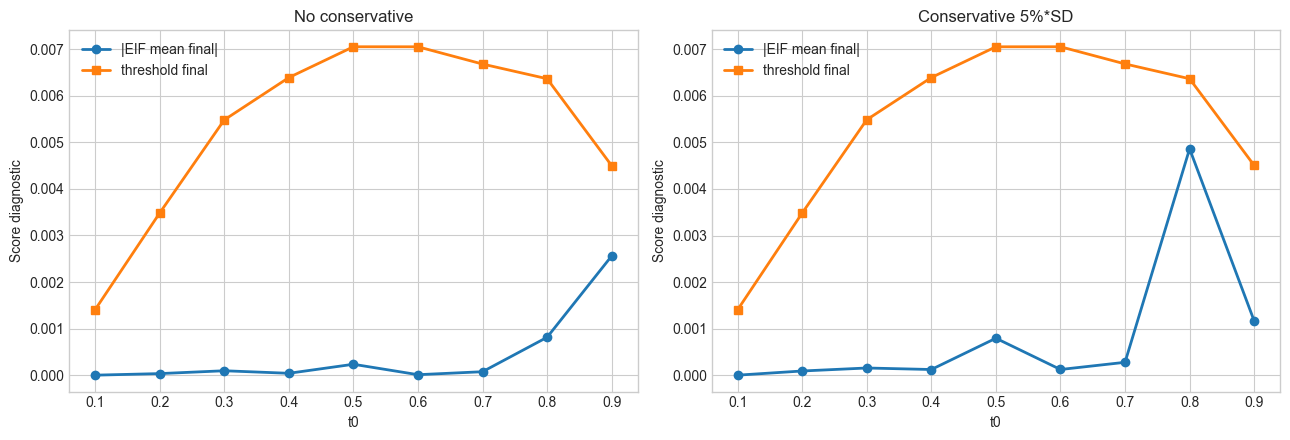

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharex=True)

for ax, label, result in [
    (axes[0], "No conservative", undersmoothed_no_cons),
    (axes[1], "Conservative 5%*SD", undersmoothed_cons),
]:
    selected = result["undersmoothed_summary"].sort_values("t0")
    ax.plot(
        selected["t0"],
        np.abs(selected["eif_mean_final"]),
        marker="o",
        linewidth=2,
        label="|EIF mean final|",
    )
    ax.plot(
        selected["t0"],
        selected["threshold_final"],
        marker="s",
        linewidth=2,
        label="threshold final",
    )
    ax.set_title(label)
    ax.set_xlabel("t0")
    ax.set_ylabel("Score diagnostic")
    ax.legend()

plt.tight_layout()
plt.show()

## Survival and Density Views

- Survival panel compares stage-1 `CV-IPCW`, no-undersmoothing `CV-IPCW-L1MLE`, and plug-in undersmoothed `CV-IPCW-L1MLE`.
- Density panel keeps the no-undersmoothing `CV-IPCW-L1MLE` as the post-IPCW L1 baseline (undersmoothing is a survival-oriented adjustment).

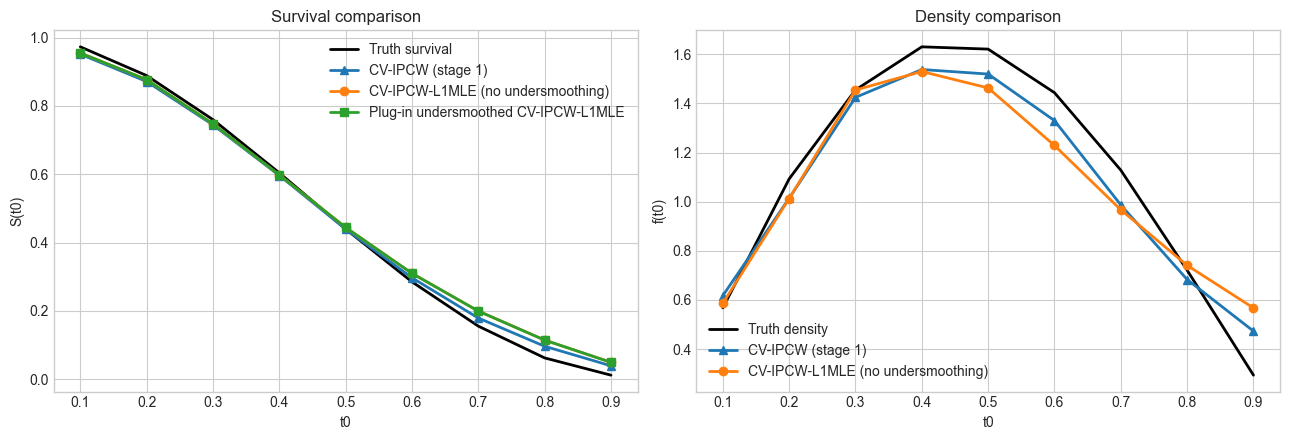

In [9]:
grid = np.asarray(TARGETING_POINTS, dtype=float)
truth_survival = np.asarray(truth.survival_fn(grid), dtype=float)
truth_density = np.asarray(truth.density_fn(grid), dtype=float)

stage1_survival = evaluate_survival_on_grid(plugin_no_cons["stage1_estimator"], grid)
no_us_survival = plugin_no_cons["no_undersmoothing_summary"].sort_values("t0")["psi_init"].to_numpy(dtype=float)
us_survival = undersmoothed_no_cons["undersmoothed_summary"].sort_values("t0")["psi_init"].to_numpy(dtype=float)

stage1_density = evaluate_density_on_grid(plugin_no_cons["stage1_estimator"], grid)
no_us_density = plugin_no_cons["no_undersmoothing_summary"].sort_values("t0")["estimated_density"].to_numpy(dtype=float)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharex=True)

axes[0].plot(grid, truth_survival, color="black", linewidth=2, label="Truth survival")
axes[0].plot(grid, stage1_survival, marker="^", linewidth=2, label="CV-IPCW (stage 1)")
axes[0].plot(grid, no_us_survival, marker="o", linewidth=2, label="CV-IPCW-L1MLE (no undersmoothing)")
axes[0].plot(grid, us_survival, marker="s", linewidth=2, label="Plug-in undersmoothed CV-IPCW-L1MLE")
axes[0].set_title("Survival comparison")
axes[0].set_xlabel("t0")
axes[0].set_ylabel("S(t0)")
axes[0].legend()

axes[1].plot(grid, truth_density, color="black", linewidth=2, label="Truth density")
axes[1].plot(grid, stage1_density, marker="^", linewidth=2, label="CV-IPCW (stage 1)")
axes[1].plot(grid, no_us_density, marker="o", linewidth=2, label="CV-IPCW-L1MLE (no undersmoothing)")
axes[1].set_title("Density comparison")
axes[1].set_xlabel("t0")
axes[1].set_ylabel("f(t0)")
axes[1].legend()

plt.tight_layout()
plt.show()